# Random Forest Weather Type Classification

This notebook builds one model only: a Random Forest classifier for the Kaggle Weather Type Classification dataset. It includes preprocessing in a scikit-learn pipeline for numeric and categorical columns.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

## 2. Load Dataset



In [2]:
DATA_PATH = "weather_classification_data.csv"

df = pd.read_csv(DATA_PATH)
df.head()

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy


In [3]:
print("Dataset shape:", df.shape)
display(df.info())
df.describe(include="all")

Dataset shape: (13200, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13200 entries, 0 to 13199
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temperature           13200 non-null  float64
 1   Humidity              13200 non-null  int64  
 2   Wind Speed            13200 non-null  float64
 3   Precipitation (%)     13200 non-null  float64
 4   Cloud Cover           13200 non-null  object 
 5   Atmospheric Pressure  13200 non-null  float64
 6   UV Index              13200 non-null  int64  
 7   Season                13200 non-null  object 
 8   Visibility (km)       13200 non-null  float64
 9   Location              13200 non-null  object 
 10  Weather Type          13200 non-null  object 
dtypes: float64(5), int64(2), object(4)
memory usage: 1.1+ MB


None

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
count,13200.000000,13200.000000,13200.000000,13200.000000,13200,13200.000000,13200.000000,13200,13200.000000,13200,13200
unique,NaN,NaN,NaN,NaN,4,NaN,NaN,4,NaN,3,4
top,NaN,NaN,NaN,NaN,overcast,NaN,NaN,Winter,NaN,inland,Rainy
freq,NaN,NaN,NaN,NaN,6090,NaN,NaN,5610,NaN,4816,3300
mean,19.127576,68.710833,9.832197,53.644394,NaN,1005.827896,4.005758,NaN,5.462917,NaN,NaN
std,17.386327,20.194248,6.908704,31.946541,NaN,37.199589,3.856600,NaN,3.371499,NaN,NaN
min,-25.000000,20.000000,0.000000,0.000000,NaN,800.120000,0.000000,NaN,0.000000,NaN,NaN
25%,4.000000,57.000000,5.000000,19.000000,NaN,994.800000,1.000000,NaN,3.000000,NaN,NaN
50%,21.000000,70.000000,9.000000,58.000000,NaN,1007.650000,3.000000,NaN,5.000000,NaN,NaN
75%,31.000000,84.000000,13.500000,82.000000,NaN,1016.772500,7.000000,NaN,7.500000,NaN,NaN


## 3. Split Features and Target

In [4]:
TARGET_COLUMN = "Weather Type"

if TARGET_COLUMN not in df.columns:
    raise ValueError(f"Expected target column '{TARGET_COLUMN}', but found: {list(df.columns)}")

X = df.drop(columns=[TARGET_COLUMN])

# Encode the target weather condition labels as numbers.
target_encoder = LabelEncoder()
y = target_encoder.fit_transform(df[TARGET_COLUMN])
target_mapping = dict(zip(target_encoder.classes_, target_encoder.transform(target_encoder.classes_)))

print("Feature columns:", list(X.columns))
print("Target encoding:", target_mapping)

Feature columns: ['Temperature', 'Humidity', 'Wind Speed', 'Precipitation (%)', 'Cloud Cover', 'Atmospheric Pressure', 'UV Index', 'Season', 'Visibility (km)', 'Location']
Target encoding: {'Cloudy': np.int64(0), 'Rainy': np.int64(1), 'Snowy': np.int64(2), 'Sunny': np.int64(3)}


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 10560
Testing rows: 2640


## 4. Preprocessing and Random Forest Pipeline

Numeric columns use median imputation for missing values. Categorical columns use most-frequent imputation and one-hot encoding. Random Forest does not require feature scaling, so scaling is intentionally not included.

In [6]:
numeric_features = X.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
condition_features = [col for col in ["Cloud Cover", "Season", "Location"] if col in X.columns]

print("Numeric features:", numeric_features)
print("Categorical features encoded with OneHotEncoder:", categorical_features)
print("Condition features:", condition_features)

Numeric features: ['Temperature', 'Humidity', 'Wind Speed', 'Precipitation (%)', 'Atmospheric Pressure', 'UV Index', 'Visibility (km)']
Categorical features encoded with OneHotEncoder: ['Cloud Cover', 'Season', 'Location']
Condition features: ['Cloud Cover', 'Season', 'Location']


The next cell shows what condition encoding looks like. The model still uses the pipeline below so encoding is learned only from the training data.

In [7]:
if condition_features:
    encoded_condition_preview = pd.get_dummies(
        X[condition_features],
        columns=condition_features,
        dtype=int
    )
    display(encoded_condition_preview.head())
else:
    print("No condition columns found for encoding.")

,Cloud Cover_clear,Cloud Cover_cloudy,Cloud Cover_overcast,Cloud Cover_partly cloudy,Season_Autumn,Season_Spring,Season_Summer,Season_Winter,Location_coastal,Location_inland,Location_mountain
0,0,0,0,1,0,0,0,1,0,1,0
1,0,0,0,1,0,1,0,0,0,1,0
2,1,0,0,0,0,1,0,0,0,0,1
3,1,0,0,0,0,1,0,0,1,0,0
4,0,0,1,0,0,0,0,1,0,0,1


In [8]:
numeric_preprocessor = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_preprocessor = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("numeric", numeric_preprocessor, numeric_features),
    ("categorical", categorical_preprocessor, categorical_features)
])

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=1,
        class_weight="balanced"
    ))
])

rf_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Temperature', 'Humidity',
                                                   'Wind Speed',
                                                   'Precipitation (%)',
                                                   'Atmospheric Pressure',
                                                   'UV Index',
                                                   'Visibility (km)']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Cloud Cover', 'Season',
                                                   'Location'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=300, n_jobs=1,
                                        random_state=42))])

## 5. Train Model

In [9]:
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Temperature', 'Humidity',
                                                   'Wind Speed',
                                                   'Precipitation (%)',
                                                   'Atmospheric Pressure',
                                                   'UV Index',
                                                   'Visibility (km)']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Cloud Cover', 'Season',
                                                   'Location'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=300, n_jobs=1,
                                        random_state=42))])

## 6. Evaluate Model

In [10]:
y_pred = rf_pipeline.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_encoder.classes_))

Test Accuracy: 0.9129

Classification Report:
              precision    recall  f1-score   support

      Cloudy       0.88      0.92      0.90       660
       Rainy       0.88      0.91      0.90       660
       Snowy       0.95      0.90      0.93       660
       Sunny       0.94      0.91      0.93       660

    accuracy                           0.91      2640
   macro avg       0.91      0.91      0.91      2640
weighted avg       0.91      0.91      0.91      2640



In [11]:
cm = confusion_matrix(y_test, y_pred, labels=range(len(target_encoder.classes_)))
cm_df = pd.DataFrame(cm, index=target_encoder.classes_, columns=target_encoder.classes_)
cm_df

,Cloudy,Rainy,Snowy,Sunny
Cloudy,609,38,6,7
Rainy,33,603,12,12
Snowy,23,21,596,20
Sunny,27,20,11,602


## 7. Cross-Validation

In [12]:
cv_scores = cross_val_score(rf_pipeline, X, y, cv=5, scoring="accuracy", n_jobs=1)

print("CV scores:", cv_scores)
print(f"Mean CV accuracy: {cv_scores.mean():.4f}")
print(f"CV standard deviation: {cv_scores.std():.4f}")

CV scores: [0.91590909 0.91893939 0.90681818 0.91742424 0.91287879]
Mean CV accuracy: 0.9144
CV standard deviation: 0.0043


## 8. Feature Importance

In [13]:
feature_names = rf_pipeline.named_steps["preprocessor"].get_feature_names_out()
importances = rf_pipeline.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

importance_df.head(20)

,feature,importance
0,numeric__Temperature,0.193693
6,numeric__Visibility (km),0.154026
3,numeric__Precipitation (%),0.126854
5,numeric__UV Index,0.125042
4,numeric__Atmospheric Pressure,0.118028
7,categorical__Cloud Cover_clear,0.075704
1,numeric__Humidity,0.058318
14,categorical__Season_Winter,0.044118
2,numeric__Wind Speed,0.033936
9,categorical__Cloud Cover_overcast,0.018766


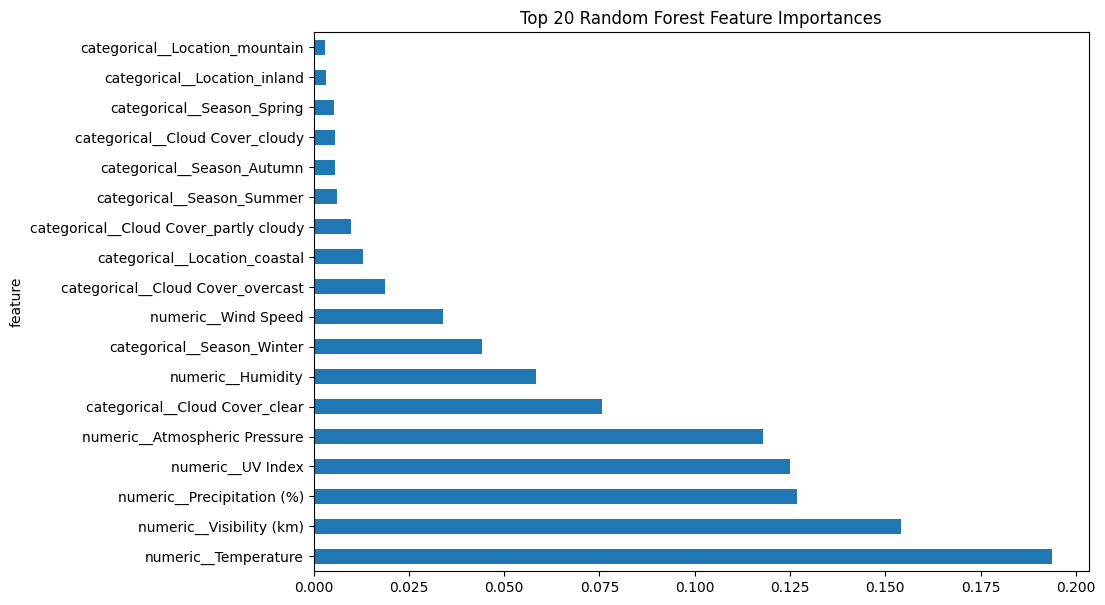

In [ ]:
importance_df.head(20).plot(
    kind="barh",
    x="feature",
    y="importance",
    figsize=(10, 7),
    legend=False,
    title="Top 20 Random Forest Feature Importances"
)

## 9. Final Test With New Weather Conditions

This final test creates new input rows using the same feature columns as the original dataset. The pipeline automatically preprocesses and encodes the condition columns before predicting.

In [ ]:
final_test_data = pd.DataFrame([
    {
        "Temperature": 5.0,
        "Humidity": 85,
        "Wind Speed": 12.0,
        "Precipitation (%)": 90.0,
        "Cloud Cover": "overcast",
        "Atmospheric Pressure": 1008.0,
        "UV Index": 1,
        "Season": "Winter",
        "Visibility (km)": 2.0,
        "Location": "inland"
    },
    {
        "Temperature": 31.0,
        "Humidity": 45,
        "Wind Speed": 4.0,
        "Precipitation (%)": 5.0,
        "Cloud Cover": "clear",
        "Atmospheric Pressure": 1020.0,
        "UV Index": 8,
        "Season": "Summer",
        "Visibility (km)": 10.0,
        "Location": "coastal"
    },
    {
        "Temperature": -6.0,
        "Humidity": 92,
        "Wind Speed": 18.0,
        "Precipitation (%)": 95.0,
        "Cloud Cover": "overcast",
        "Atmospheric Pressure": 995.0,
        "UV Index": 0,
        "Season": "Winter",
        "Visibility (km)": 1.0,
        "Location": "mountain"
    }
])

final_test_data = final_test_data[X.columns]
final_encoded_predictions = rf_pipeline.predict(final_test_data)
final_label_predictions = target_encoder.inverse_transform(final_encoded_predictions)

final_results = final_test_data.copy()
final_results["Predicted Weather Type"] = final_label_predictions
final_results

In [ ]:
final_probabilities = rf_pipeline.predict_proba(final_test_data)
probability_df = pd.DataFrame(
    final_probabilities,
    columns=[f"Probability: {label}" for label in target_encoder.classes_]
)

pd.concat([final_results[["Predicted Weather Type"]], probability_df], axis=1)